# ndispers — basic usage

`ndispers` computes refractive-index dispersion of crystals and glasses used in
nonlinear and ultrafast optics: refractive index, group-velocity quantities,
the thermo-optic coefficient dn/dT, walk-off angles and phase-matching
conditions. Everything is evaluated from Sellmeier equations (empirical fits of
refractive index as a function of wavelength) taken from published literature.

The rhythm of this notebook, repeated in every section, is:
**first ask the crystal object what it knows about itself, then compute.**
Every medium carries its formula, its coefficients, its validity range and the
reference it came from. Checking them takes three lines and tells you exactly
what you are about to calculate.

To run this notebook yourself:

```
pip install ndispers matplotlib jupyterlab
```

## 1. Find your crystal

All media live under `nd.media.crystals` and `nd.media.glasses`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ndispers as nd

print("ndispers", nd.__version__)

ndispers 0.9.0


In [2]:
names = [n for n in dir(nd.media.crystals) if not n.startswith("_")]
print(len(names), "crystal classes:")
for name in names:
    print("  ", name)

31 crystal classes:
   AlphaBBO
   BetaBBO_Eimerl1987
   BetaBBO_Ghosh1995
   BetaBBO_KK2010
   BetaBBO_Tamosauskas2018
   CLBO
   Calcite
   KBBF
   KDP
   KTP_xy
   KTP_yz
   KTP_zx
   LB4
   LBO_Castech_xy
   LBO_Castech_yz
   LBO_Castech_zx
   LBO_Ghosh1995_xy
   LBO_Ghosh1995_yz
   LBO_Ghosh1995_zx
   LBO_KK1994_xy
   LBO_KK1994_yz
   LBO_KK1994_zx
   LBO_KK2018_xy
   LBO_KK2018_yz
   LBO_KK2018_zx
   LBO_Newlight_xy
   LBO_Newlight_yz
   LBO_Newlight_zx
   RBBF
   SLN
   SLT


The suffix names the literature source of the coefficients:
`BetaBBO_Eimerl1987` implements the Sellmeier equation of Eimerl et al. (1987).
Several crystals come in more than one parameterisation (coefficient set fitted
by different authors or vendors) — β-BBO has four, LBO has five per principal
plane. Which set to trust is a physics judgement, so the package keeps them
side by side and lets you choose; we compare them in section 3.

In JupyterLab, typing `nd.media.crystals.` and pressing Tab shows this list as
completions.

## 2. Ask the crystal before you compute

Make an instance and read its own description first. At a live IPython or
Jupyter prompt the quickest way is the question-mark suffix,

```python
bbo?
```

which pops up the same description in a help pane. That pane is transient —
it leaves no trace in a saved notebook — so on this rendered page we print
the text instead:

In [3]:
bbo = nd.media.crystals.BetaBBO_Eimerl1987()
print(bbo.__doc__)   # at your own prompt, just type:  bbo?


    β-BBO (β-BaB₂O₄, barium borate) crystal

    - Point group : 3m  (C3v)
    - Crystal system : Trigonal
    - Dielectric principal axis, z // c-axis (x, y-axes are arbitrary)
    - Negative uniaxial, with optic axis parallel to z-axis
    - Transparency range : 0.19 µm to 2.6 µm

    Sellmeier equation
    ------------------
        n(wl) = sqrt(A_i + B_i/(wl**2 - C_i) - D_i * wl**2) + dn/dT * (T - 20)  for i = o, e
    
    Validity range
    ---------------
    0.22 to 1.06 µm

    Ref
    ---
    Sellmeier equation:
      Eimerl, D., Davis, L., Velsko, S., et al. (1987). Optical, mechanical, and thermal properties of barium borate. Journal of Applied Physics, 62(5), 1968-1983. https://doi.org/10.1063/1.339536

    Thermo-optic coefficients:
      Nikogosyan, D. N. (1991). Beta barium borate (BBO): a review of its properties and applications. Applied Physics A, 52(6), 359-368. https://doi.org/10.1007/bf00323647

    Nonlinear optical coefficients:
      Shoji, I., Kondo, T., & It

Four things worth reading here: the crystal class (uniaxial — one symmetry
axis, so two principal refractive indices, ordinary and extraordinary), the
Sellmeier equation being implemented, the wavelength range over which the fit
is valid, and the papers the coefficients come from. `help(bbo)` prints the
same text followed by the documentation of every method.

### The formula, exactly as evaluated

`n_expr(pol)` returns the implemented equation as a symbolic expression (a
`sympy` object, which Jupyter renders as mathematics). This is not a quotation
from the paper — it *is* the formula the package evaluates, with the
coefficients already substituted. Here λ is the wavelength in µm and T the
temperature in °C:

In [4]:
bbo.n_expr('o')

-1.66e-5*T + sqrt(-0.0155*lambda**2 + 2.7405 + 0.0184/(lambda**2 - 0.0179)) + 0.000332

Note that the expression may appear in an equivalent rearranged form rather
than letter-for-letter as written in the paper: here the temperature term
dn/dT × (T − 20) has been expanded into −1.66×10⁻⁵ T + 0.000332. The
mathematics is identical.

Every derivative-based quantity in this notebook — group velocity,
group-velocity dispersion, dn/dT — is obtained by differentiating this
expression symbolically, not by numerical finite differences. What you compute
is exactly what you see.

The extraordinary-ray expression `bbo.n_expr('e')` additionally contains the
angle θ between the wavevector and the optic axis; we will use that fact in
section 6.

The coefficient values themselves, and the geometry attributes, complete the
picture:

In [5]:
bbo.constants

{'_A_o': 2.7405,
 '_B_o': 0.0184,
 '_C_o': 0.0179,
 '_D_o': 0.0155,
 '_A_e': 2.373,
 '_B_e': 0.0128,
 '_C_e': 0.0156,
 '_D_e': 0.0044,
 '_dndT_o': -1.66e-05,
 '_dndT_e': -9.3e-06,
 '_d31_1064shg': 0.04,
 '_d22_1064shg': 2.2}

In [6]:
print("plane     :", bbo.plane)
print("theta_rad :", bbo.theta_rad)
print("phi_rad   :", bbo.phi_rad)

plane     : arb
theta_rad : var
phi_rad   : arb


`theta_rad` is `'var'` (variable): the angle argument you will pass to the
methods of *this* crystal is θ. `'arb'` (arbitrary) means the result does not
depend on that angle — for a uniaxial crystal nothing depends on the azimuthal
angle φ. This bookkeeping becomes important for biaxial crystals in section 6,
where the meaning of the angle argument changes from class to class.

So the pre-flight check is four short lines:
`x?` for provenance and validity range, `x.n_expr(pol)` for the exact
formula, `x.constants` for the numbers, and the three angle attributes for
what the angle argument means.

## 3. Compute the refractive index

In [7]:
n_o = bbo.n(0.532, 0, 25, pol='o')
n_e = bbo.n(0.532, np.pi/2, 25, pol='e')
n_o, n_e

(1.674884049110459, 1.5554658787525484)

The four arguments are wavelength (µm), angle θ (rad), temperature (°C) and
polarization (`pol='o'` or `'e'`, default `'o'`). Scalar input returns a
float. Any argument also accepts a numpy array, so a dispersion curve is one
call. We plot over 0.22–1.06 µm — the validity range we read off in
section 2:

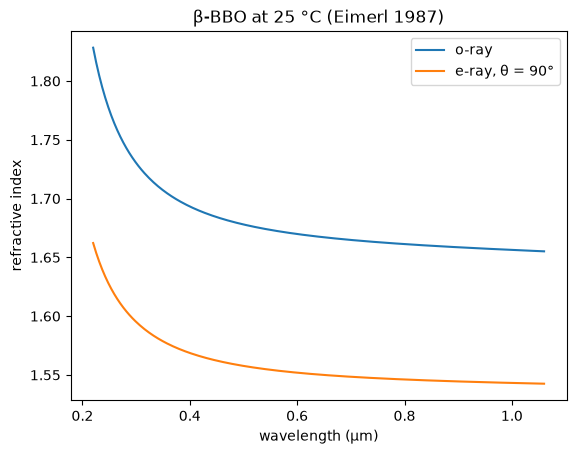

In [8]:
wl = np.linspace(0.22, 1.06, 300)

plt.plot(wl, bbo.n(wl, 0, 25, pol='o'), label="o-ray")
plt.plot(wl, bbo.n(wl, np.pi/2, 25, pol='e'), label="e-ray, θ = 90°")
plt.xlabel("wavelength (µm)")
plt.ylabel("refractive index")
plt.title("β-BBO at 25 °C (Eimerl 1987)")
plt.legend()
plt.show()

### Comparing literature sources

The four β-BBO parameterisations do not agree perfectly — they are independent
fits to different measurements. The spread is a few parts in 10⁴, and it is
largest outside the region where all fits are well constrained:

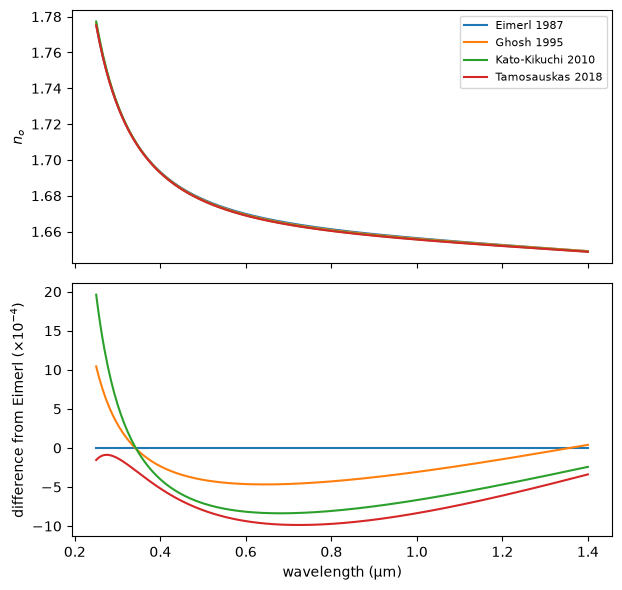

In [9]:
sources = {
    "Eimerl 1987":       nd.media.crystals.BetaBBO_Eimerl1987(),
    "Ghosh 1995":        nd.media.crystals.BetaBBO_Ghosh1995(),
    "Kato-Kikuchi 2010": nd.media.crystals.BetaBBO_KK2010(),
    "Tamosauskas 2018":  nd.media.crystals.BetaBBO_Tamosauskas2018(),
}
wl = np.linspace(0.25, 1.4, 300)
reference = sources["Eimerl 1987"].n(wl, 0, 25, pol='o')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6.4, 6))
for label, medium in sources.items():
    n = medium.n(wl, 0, 25, pol='o')
    ax1.plot(wl, n, label=label)
    ax2.plot(wl, (n - reference) * 1e4)
ax1.set_ylabel("$n_o$")
ax1.legend(fontsize=8)
ax2.set_xlabel("wavelength (µm)")
ax2.set_ylabel(r"difference from Eimerl ($\times 10^{-4}$)")
plt.tight_layout()
plt.show()

When the fourth decimal of the refractive index matters (it does for
phase-matching angles), check the validity range of each source with
`print(x.__doc__)` and pick deliberately.

## 4. Group-velocity quantities, temperature, walk-off

All dispersion methods take the same four arguments as `n`. The
derivative-based quantities for ultrashort-pulse work:

In [10]:
wl0 = 0.8  # µm
print("GD  (group delay)               :", bbo.GD(wl0, 0, 25, pol='o'), "fs/mm")
print("GV  (group velocity)            :", bbo.GV(wl0, 0, 25, pol='o'), "µm/fs")
print("ng  (group index)               :", bbo.ng(wl0, 0, 25, pol='o'))
print("GVD (group-velocity dispersion) :", bbo.GVD(wl0, 0, 25, pol='o'), "fs²/mm")
print("TOD (third-order dispersion)    :", bbo.TOD(wl0, 0, 25, pol='o'), "fs³/mm")

GD  (group delay)               : 5622.473709634754 fs/mm
GV  (group velocity)            : 0.17785765690400382 µm/fs
ng  (group index)               : 1.6855752134517816
GVD (group-velocity dispersion) : 71.86403019943364 fs²/mm
TOD (third-order dispersion)    : 50.967738254318164 fs³/mm


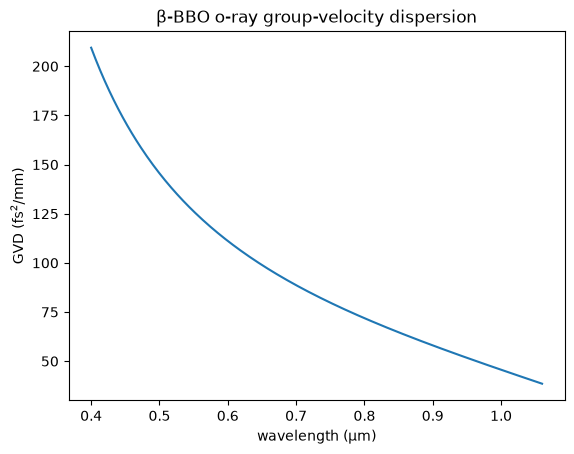

In [11]:
wl = np.linspace(0.4, 1.06, 300)
plt.plot(wl, bbo.GVD(wl, 0, 25, pol='o'))
plt.xlabel("wavelength (µm)")
plt.ylabel("GVD (fs$^2$/mm)")
plt.title("β-BBO o-ray group-velocity dispersion")
plt.show()

The thermo-optic coefficient dn/dT comes from the same symbolic expression,
differentiated with respect to T. For this parameterisation the temperature
dependence is linear in T, so dn/dT is constant in temperature (but not in
wavelength):

dn_o/dT at 0.532 µm : -1.66e-05 1/K


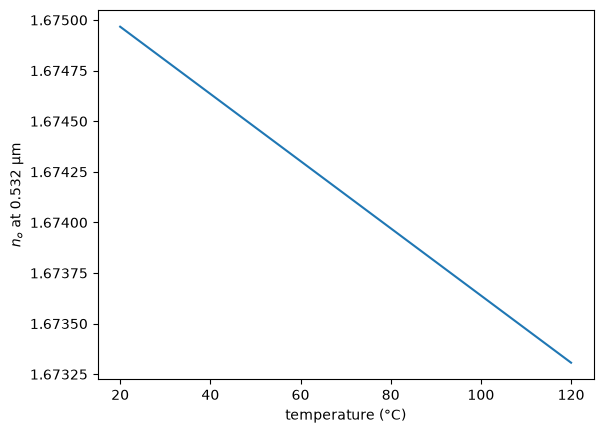

In [12]:
print("dn_o/dT at 0.532 µm :", bbo.dndT(0.532, 0, 25, pol='o'), "1/K")

T = np.linspace(20, 120, 200)
plt.plot(T, bbo.n(0.532, 0, T, pol='o'))
plt.xlabel("temperature (°C)")
plt.ylabel("$n_o$ at 0.532 µm")
plt.show()

For the extraordinary ray at intermediate angles, the direction of energy
flow deviates from the wavevector — the walk-off angle:

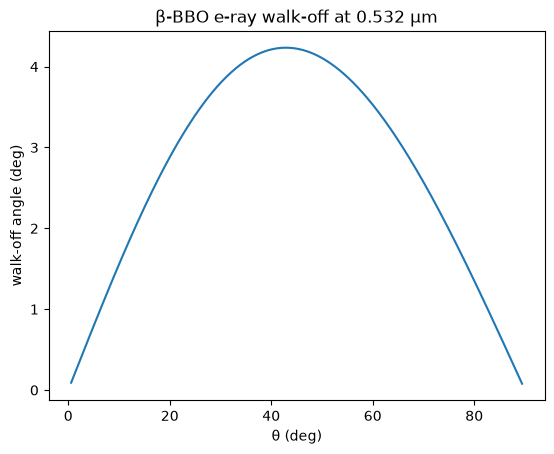

In [13]:
theta = np.linspace(0.01, np.pi/2 - 0.01, 300)
rho = bbo.woa_theta(0.532, theta, 25, pol='e')   # rad
plt.plot(np.degrees(theta), np.degrees(rho))
plt.xlabel("θ (deg)")
plt.ylabel("walk-off angle (deg)")
plt.title("β-BBO e-ray walk-off at 0.532 µm")
plt.show()

## 5. Phase matching

Second-harmonic generation is the special case of sum-frequency generation
with two equal input wavelengths. A collinear process is phase-matched when
the wavevector mismatch Δk = k₃ − k₂ − k₁ vanishes; in a birefringent crystal
this can be arranged by choosing the propagation angle. `pmAngles_sfg` solves
for those angles directly:

In [14]:
pm = bbo.pmAngles_sfg(1.064, 1.064, 25, deg=True)
pm

{'wl3': 0.532,
 'ooe': {'theta': [22.884169498625802], 'phi': None},
 'eeo': {'theta': [], 'phi': None},
 'oee': {'theta': [32.56045545648089], 'phi': None},
 'eoe': {'theta': [32.56045545648089], 'phi': None},
 'eoo': {'theta': [], 'phi': None},
 'oeo': {'theta': [], 'phi': None}}

The three-letter keys give the polarizations of (wave 1, wave 2, sum wave):
`'ooe'` means both inputs ordinary and the sum-frequency wave extraordinary —
Type I in the usual nomenclature; `'oee'`/`'eoe'` are Type II. An empty list
means no phase-matching angle exists for that combination. For
1064 nm → 532 nm in β-BBO, Type I matches near θ = 22.9° and Type II near
32.6°.

To see *why* these are the answers, plot the mismatch Δk against θ — the
phase-matching angles are its zero crossings — and the corresponding
conversion-efficiency factor sinc²(ΔkL/2) for two crystal lengths L. The
longer the crystal, the narrower the angular acceptance:

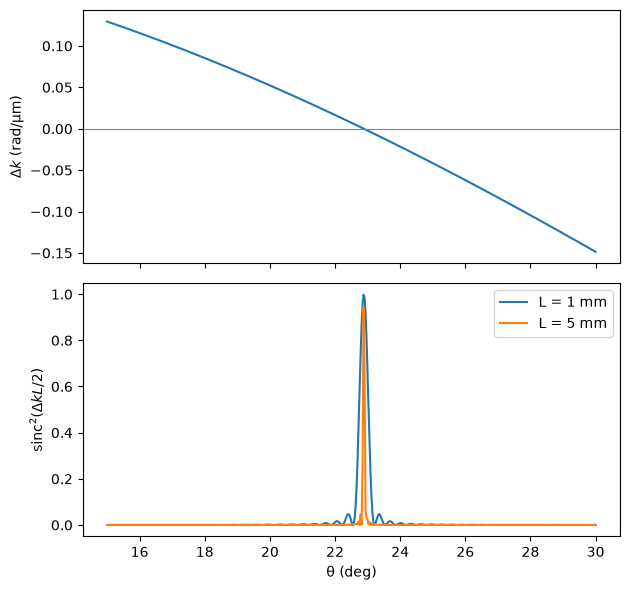

In [15]:
theta = np.linspace(np.radians(15), np.radians(30), 500)
dk = bbo.dk_sfg(1.064, 1.064, theta, 25, 'o', 'o', 'e')   # rad/µm

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6.4, 6))
ax1.plot(np.degrees(theta), dk)
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_ylabel(r"$\Delta k$ (rad/µm)")

for L_mm in (1, 5):
    ax2.plot(np.degrees(theta),
             bbo.pmFactor_sfg(1.064, 1.064, theta, 25, 'o', 'o', 'e', L_mm),
             label=f"L = {L_mm} mm")
ax2.set_xlabel("θ (deg)")
ax2.set_ylabel(r"$\mathrm{sinc}^2(\Delta k L / 2)$")
ax2.legend()
plt.tight_layout()
plt.show()

Sweeping the fundamental wavelength gives the Type-I tuning curve:

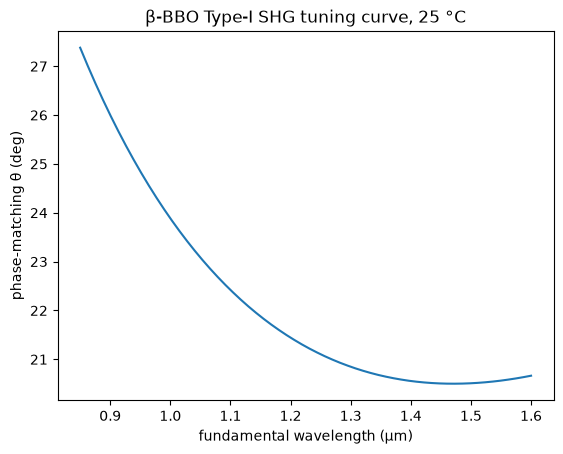

In [16]:
fund = np.linspace(0.85, 1.6, 60)
theta_pm = []
for w in fund:
    sol = bbo.pmAngles_sfg(w, w, 25, deg=True)['ooe']['theta']
    theta_pm.append(sol[0] if sol else np.nan)

plt.plot(fund, theta_pm)
plt.xlabel("fundamental wavelength (µm)")
plt.ylabel("phase-matching θ (deg)")
plt.title("β-BBO Type-I SHG tuning curve, 25 °C")
plt.show()

## 6. Biaxial crystals and glasses

A biaxial crystal (three distinct principal refractive indices) is handled one
principal plane at a time — one class per plane. This is where the section-2
habit pays off: the angle attributes tell you what the angle argument means in
each plane, because it is *not* always θ.

In [17]:
ktp_xy = nd.media.crystals.KTP_xy()
ktp_zx = nd.media.crystals.KTP_zx()

for x in (ktp_xy, ktp_zx):
    print(f"{type(x).__name__:8s}  plane={x.plane}  theta_rad={x.theta_rad}  phi_rad={x.phi_rad}")

KTP_xy    plane=xy  theta_rad=1.5707963267948966  phi_rad=var
KTP_zx    plane=zx  theta_rad=var  phi_rad=1.5707963267948966


In the xy plane θ is fixed at 90° and the varying angle — the second argument
of every method — is φ. In the zx plane it is θ. Asking the symbolic
expression which variables it actually contains makes the same point from the
formula side:

In [18]:
print("KTP_zx e-ray expression depends on:",
      sorted(map(str, ktp_zx.n_expr('e').free_symbols)))
print("KTP_zx o-ray expression depends on:",
      sorted(map(str, ktp_zx.n_expr('o').free_symbols)))

KTP_zx e-ray expression depends on: ['T', 'lambda', 'theta']
KTP_zx o-ray expression depends on: ['T', 'lambda']


`nd.media.glasses` holds the optically isotropic media. Having a single
refractive index with no direction dependence, they take only wavelength and
temperature — there is no angle or polarization to specify:

In [19]:
silica = nd.media.glasses.FusedSilica()
silica.n(1.064, 20)

1.4495857898590634

The split between `crystals` and `glasses` is by optical isotropy, not by
whether a medium is crystalline: `CaF₂` is a cubic crystal and lives with the
glasses because it has no birefringence. α-BBO and calcite are centrosymmetric
too, but being uniaxial they are birefringent and stay with the crystals.

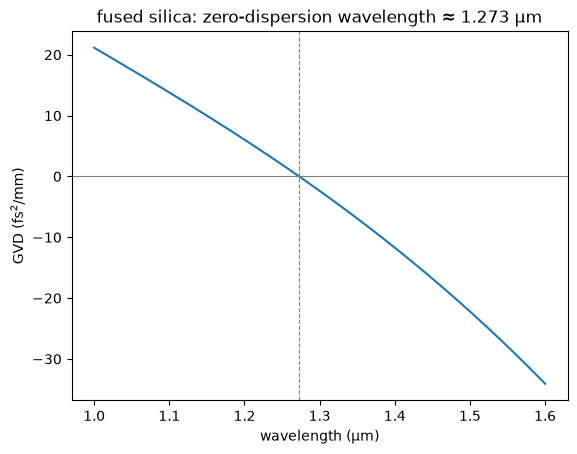

In [20]:
wl = np.linspace(1.0, 1.6, 300)
gvd = silica.GVD(wl, 20)
wl_zero = np.interp(0, -gvd, wl)   # GVD decreases through zero

plt.plot(wl, gvd)
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(wl_zero, color='gray', lw=0.8, ls='--')
plt.xlabel("wavelength (µm)")
plt.ylabel("GVD (fs$^2$/mm)")
plt.title(f"fused silica: zero-dispersion wavelength ≈ {wl_zero:.3f} µm")
plt.show()

## Where to go next

- The [media catalog](https://ndispers.readthedocs.io/en/latest/api.html) lists
  every crystal and glass with its formula, validity range and references —
  the same information you get from `print(x.__doc__)`.
- Medium objects are picklable (serializable with Python's built-in `pickle`),
  so they can be passed directly to `multiprocessing` or `joblib` workers for
  parameter scans.
- Missing a crystal? Request or contribute it on
  [GitHub](https://github.com/akihiko-shimura/ndispers/issues).